<a href="https://colab.research.google.com/github/COMPUTE-LU/AI4MedLife_LMs-Agents_2026/blob/main/HuggingFace_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HuggingFace Tutorial

Hugging Face is a platform and open-source community that provides tools, datasets, and pre-trained machine learning models, especially for natural language processing and AI. It allows users to discover, share, and use models and datasets for computational experiments and machine learning applications.

This notebook introduces you to HuggingFace models and its transformers library.

Where you do not understand the code, use a chatbot to explain it to you.

#Exercise 1: Tokenization
This exercise demonstrates the difference between different tokenizers.

In [1]:
#Import the tokenizer from the Transformers library
from transformers import AutoTokenizer

In [2]:
# General English tokenizer
english_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Chemistry tokenizer
chemistry_tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

# Biomedical tokenizer
biomedical_tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
)

# Define your test sentence
text = "The molecule 1-(2,4-dichlorophenyl)-3-(1H-imidazol-1-yl)propan-2-one inhibits CYP3A4."

# Tokenize with all models
english_tokens = english_tokenizer.tokenize(text)
chemistry_tokens = chemistry_tokenizer.tokenize(text)
biomedical_tokens = biomedical_tokenizer.tokenize(text)

# Print the results

print("Original text:")
print(text)

print("\nGeneral English tokenizer:")
print(english_tokens)
print("Number of tokens:", len(english_tokens))

print("\nChemistry tokenizer:")
print(chemistry_tokens)
print("Number of tokens:", len(chemistry_tokens))

print("\nBiomedical tokenizer:")
print(biomedical_tokens)
print("Number of tokens:", len(biomedical_tokens))

Original text:
The molecule 1-(2,4-dichlorophenyl)-3-(1H-imidazol-1-yl)propan-2-one inhibits CYP3A4.

General English tokenizer:
['the', 'molecule', '1', '-', '(', '2', ',', '4', '-', 'di', '##ch', '##lor', '##op', '##hen', '##yl', ')', '-', '3', '-', '(', '1', '##h', '-', 'im', '##ida', '##zo', '##l', '-', '1', '-', 'y', '##l', ')', 'prop', '##an', '-', '2', '-', 'one', 'inhibit', '##s', 'cy', '##p', '##3', '##a', '##4', '.']
Number of tokens: 47

Chemistry tokenizer:
['T', 'h', 'e', 'Ġ', 'm', 'o', 'l', 'e', 'c', 'u', 'l', 'e', 'Ġ', '1', '-', '(', '2', ',', '4', '-', 'd', 'i', 'c', 'h', 'l', 'o', 'r', 'o', 'p', 'h', 'e', 'n', 'y', 'l', ')-', '3', '-', '(', '1', 'H', '-', 'i', 'm', 'i', 'd', 'a', 'z', 'o', 'l', '-', '1', '-', 'y', 'l', ')', 'p', 'r', 'o', 'p', 'a', 'n', '-', '2', '-', 'on', 'e', 'Ġ', 'i', 'n', 'h', 'i', 'b', 'i', 't', 's', 'Ġ', 'C', 'Y', 'P', '3', 'A', '4', '.']
Number of tokens: 83

Biomedical tokenizer:
['the', 'molecule', '1', '-', '(', '2', ',', '4', '-', 'dichloro

In [3]:
# More texts
texts = [
    "The protein binds to ATP with high affinity.",
    "Aspirin has the molecular formula C9H8O4.",
    "CC(=O)OC1=CC=CC=C1C(=O)O",  # SMILES representation of aspirin
]

# Loop through the texts
for text in texts:
    print("\n" + "=" * 60)
    print("Text:", text)

    print("\nEnglish:", english_tokenizer.tokenize(text))
    print("Chemistry:", chemistry_tokenizer.tokenize(text))
    print("Biomedical:", biomedical_tokenizer.tokenize(text))


Text: The protein binds to ATP with high affinity.

English: ['the', 'protein', 'binds', 'to', 'atp', 'with', 'high', 'affinity', '.']
Chemistry: ['T', 'h', 'e', 'Ġ', 'p', 'r', 'o', 't', 'e', 'i', 'n', 'Ġ', 'b', 'i', 'n', 'd', 's', 'Ġ', 't', 'o', 'Ġ', 'A', 'T', 'P', 'Ġ', 'w', 'i', 't', 'h', 'Ġ', 'h', 'i', 'g', 'h', 'Ġ', 'a', 'f', 'f', 'i', 'n', 'i', 't', 'y', '.']
Biomedical: ['the', 'protein', 'binds', 'to', 'atp', 'with', 'high', 'affinity', '.']

Text: Aspirin has the molecular formula C9H8O4.

English: ['as', '##pi', '##rin', 'has', 'the', 'molecular', 'formula', 'c', '##9', '##h', '##8', '##o', '##4', '.']
Chemistry: ['A', 's', 'p', 'i', 'r', 'i', 'n', 'Ġ', 'h', 'a', 's', 'Ġ', 't', 'h', 'e', 'Ġ', 'm', 'o', 'l', 'e', 'c', 'u', 'l', 'a', 'r', 'Ġ', 'f', 'o', 'r', 'm', 'u', 'l', 'a', 'Ġ', 'C', '9', 'H', '8', 'O', '4', '.']
Biomedical: ['aspirin', 'has', 'the', 'molecular', 'formula', 'c9', '##h', '##8', '##o4', '.']

Text: CC(=O)OC1=CC=CC=C1C(=O)O

English: ['cc', '(', '=', 'o', ')',

## TASK
a) Try out other sentences and tokenizers.

b) Try out text examples that are longer than one sentence.

c) Reflect on the differences  you have observed.

# Exercise 2: Text classification
This exercise will demonstrate how to classify sentences (here the classification is binary: neuroscience vs oncology). For the sake of simplification, there is no separate hold-out test set to evaluate generalization on.

In [4]:
# Imports
import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect ide


Epoch: 1
-------------------
Training:
  Loss:       0.677
  Accuracy:   0.625
  Precision:  0.68
  Recall:     0.625
  F1-score:   0.584

Validation:
  Loss:       0.736
  Accuracy:   0.312
  Precision:  0.156
  Recall:     0.312
  F1-score:   0.208

Epoch: 2
-------------------
Training:
  Loss:       0.633
  Accuracy:   0.75
  Precision:  0.831
  Recall:     0.75
  F1-score:   0.73

Validation:
  Loss:       0.727
  Accuracy:   0.438
  Precision:  0.191
  Recall:     0.438
  F1-score:   0.266

Epoch: 3
-------------------
Training:
  Loss:       0.591
  Accuracy:   0.896
  Precision:  0.913
  Recall:     0.896
  F1-score:   0.894

Validation:
  Loss:       0.715
  Accuracy:   0.5
  Precision:  0.767
  Recall:     0.5
  F1-score:   0.391


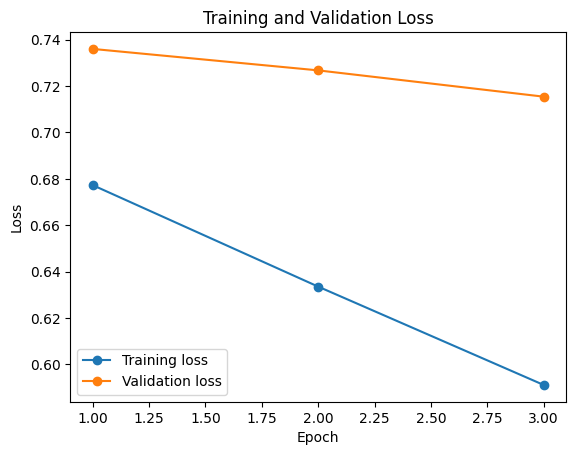

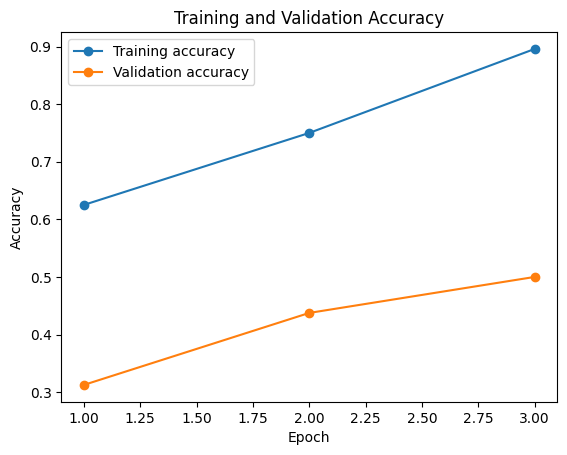

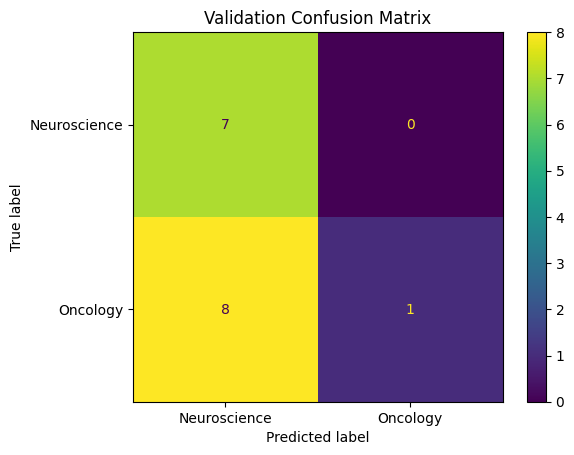

In [5]:
# Classify sentences as neuroscience (0) or oncology (1)

# ---------------------------------------------------------
# 1. Data
# ---------------------------------------------------------

neuroscience = [

    "Hippocampal neurons were cultured for seven days before recording.",
    "The experiment measured calcium signals in cortical neurons.",
    "Dopamine release in the striatum was measured after stimulation.",
    "Researchers recorded action potentials from pyramidal neurons.",
    "Optogenetic stimulation was used to activate dopaminergic neurons.",
    "Neuronal cultures were treated with a selective GABA receptor antagonist.",
    "The researchers measured synaptic transmission between cultured neurons.",
    "RNA sequencing revealed changes in gene expression after neuronal activation.",
    "Immunohistochemistry was used to identify neurons expressing tyrosine hydroxylase.",
    "The experiment examined axonal growth following neuronal injury.",
    "Researchers measured long-term potentiation in hippocampal slices.",
    "The study investigated the effect of serotonin on neuronal firing.",
    "Microglial activation was measured after experimental brain injury.",
    "Electrophysiological recordings were obtained from cortical neurons.",
    "The researchers examined dendritic spine density in the hippocampus.",
    "Neural stem cells were differentiated into dopaminergic neurons.",
    "The researchers measured synaptic plasticity in cultured hippocampal neurons.",
    "Calcium imaging was used to monitor neuronal activity during stimulation.",
    "The experiment examined changes in cortical neuron connectivity.",
    "Researchers measured glutamate release from cultured neurons.",
    "Dopaminergic neurons were exposed to oxidative stress in culture.",
    "The study investigated the effect of dopamine on neuronal survival.",
    "Researchers examined gene expression in activated microglia.",
    "Electrophysiological recordings were used to measure neuronal firing rates.",
    "The experiment examined dendritic branching in developing neurons.",
    "Researchers investigated the role of NMDA receptors in synaptic plasticity.",
    "Neural progenitor cells were analyzed during neuronal differentiation.",
    "The study measured acetylcholine release from cultured neural cells.",
    "Researchers examined changes in synaptic density following stimulation.",
    "The experiment investigated axonal regeneration after nerve injury.",
    "Brain tissue was analyzed for expression of neuronal markers.",
    "The researchers measured inhibitory signaling between cortical neurons.",

]


oncology = [

    "Cancer cells were treated with increasing concentrations of the drug.",
    "The experiment measured proliferation of breast cancer cells.",
    "CRISPR knockout of TP53 increased resistance to apoptosis.",
    "Tumor spheroids were cultured to study chemotherapy resistance.",
    "The researchers measured DNA damage after radiation exposure.",
    "RNA sequencing revealed upregulation of oncogenic signaling pathways.",
    "Western blotting showed increased expression of phosphorylated EGFR.",
    "The mouse xenograft model was used to evaluate tumor growth.",
    "Flow cytometry was used to quantify apoptosis in treated cancer cells.",
    "The experiment examined migration of colorectal cancer cells.",
    "Researchers investigated the effect of hypoxia on tumor cell survival.",
    "Cancer cells were exposed to a monoclonal antibody targeting HER2.",
    "The researchers measured expression of the tumor suppressor protein p53.",
    "Organoids were generated from patient-derived tumor tissue.",
    "The study investigated mechanisms of resistance to targeted therapy.",
    "Researchers measured angiogenesis in a mouse tumor model.",
    "The experiment examined proliferation of lung cancer cells.",
    "Researchers measured expression of oncogenes in tumor tissue.",
    "Cancer cells were exposed to increasing concentrations of chemotherapy.",
    "The study investigated apoptosis in drug-treated tumor cells.",
    "Researchers examined mutations in the KRAS signaling pathway.",
    "Tumor organoids were used to evaluate responses to targeted therapy.",
    "The experiment measured invasion of melanoma cells through extracellular matrix.",
    "Researchers investigated the role of VEGF in tumor blood vessel formation.",
    "DNA sequencing identified mutations associated with tumor progression.",
    "The study examined immune cell infiltration in experimental tumors.",
    "Researchers measured activation of the PI3K-AKT signaling pathway.",
    "Tumor cells were analyzed for expression of estrogen receptors.",
    "The experiment investigated mechanisms of resistance to immunotherapy.",
    "Researchers compared gene expression between normal and tumor tissue.",
    "The study measured tumor growth following treatment with a kinase inhibitor.",
    "Cancer cells were analyzed using flow cytometry after drug treatment.",

]

# Combine into one dataset
texts = neuroscience + oncology

# 0 = neuroscience, 1 = oncology
labels = [0] * len(neuroscience) + [1] * len(oncology)


# ---------------------------------------------------------
# 2. Choose a model
# ---------------------------------------------------------

model_name = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"

# The tokenizer always has to match the model
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


# ---------------------------------------------------------
# 3. Split the data
# ---------------------------------------------------------

train_texts, validation_texts, train_labels, validation_labels = train_test_split(
    texts,
    labels,
    test_size=0.25,
    random_state=42
)


# ---------------------------------------------------------
# 4. Tokenize and convert to tensors
# ---------------------------------------------------------

train_tokens = tokenizer(
    train_texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

validation_tokens = tokenizer(
    validation_texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

train_labels = torch.tensor(train_labels)
validation_labels = torch.tensor(validation_labels)


# ---------------------------------------------------------
# 5. Train
# ---------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5
)

# Store results from each epoch
train_losses = []
validation_losses = []

train_accuracies = []
validation_accuracies = []

for epoch in range(3):

    # -----------------------------------------------------
    # Train
    # -----------------------------------------------------

    model.train()

    optimizer.zero_grad()

    train_output = model(
        **train_tokens,
        labels=train_labels
    )

    train_output.loss.backward()
    optimizer.step()


    # -----------------------------------------------------
    # Evaluate
    # -----------------------------------------------------

    model.eval()

    with torch.no_grad():

        train_eval_output = model(
            **train_tokens,
            labels=train_labels
        )

        validation_output = model(
            **validation_tokens,
            labels=validation_labels
        )


    # Predictions
    train_predictions = train_eval_output.logits.argmax(dim=1).numpy()
    validation_predictions = validation_output.logits.argmax(dim=1).numpy()

    train_true = train_labels.numpy()
    validation_true = validation_labels.numpy()


    # -----------------------------------------------------
    # Calculate loss and accuracy
    # -----------------------------------------------------

    train_loss = train_eval_output.loss.item()
    validation_loss = validation_output.loss.item()

    train_accuracy = accuracy_score(
        train_true,
        train_predictions
    )

    validation_accuracy = accuracy_score(
        validation_true,
        validation_predictions
    )


    # Store results
    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    train_accuracies.append(train_accuracy)
    validation_accuracies.append(validation_accuracy)


    # -----------------------------------------------------
    # Calculate additional metrics
    # -----------------------------------------------------

    train_precision = precision_score(
        train_true,
        train_predictions,
        average="weighted",
        zero_division=0
    )

    train_recall = recall_score(
        train_true,
        train_predictions,
        average="weighted",
        zero_division=0
    )

    train_f1 = f1_score(
        train_true,
        train_predictions,
        average="weighted",
        zero_division=0
    )

    validation_precision = precision_score(
        validation_true,
        validation_predictions,
        average="weighted",
        zero_division=0
    )

    validation_recall = recall_score(
        validation_true,
        validation_predictions,
        average="weighted",
        zero_division=0
    )

    validation_f1 = f1_score(
        validation_true,
        validation_predictions,
        average="weighted",
        zero_division=0
    )


    # -----------------------------------------------------
    # Print results
    # -----------------------------------------------------

    print("\nEpoch:", epoch + 1)
    print("-------------------")

    print("Training:")
    print("  Loss:      ", round(train_loss, 3))
    print("  Accuracy:  ", round(train_accuracy, 3))
    print("  Precision: ", round(train_precision, 3))
    print("  Recall:    ", round(train_recall, 3))
    print("  F1-score:  ", round(train_f1, 3))

    print("\nValidation:")
    print("  Loss:      ", round(validation_loss, 3))
    print("  Accuracy:  ", round(validation_accuracy, 3))
    print("  Precision: ", round(validation_precision, 3))
    print("  Recall:    ", round(validation_recall, 3))
    print("  F1-score:  ", round(validation_f1, 3))


# ---------------------------------------------------------
# 6. Plot training curves
# ---------------------------------------------------------

epochs = range(1, len(train_losses) + 1)


# Loss curve
plt.figure()

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs,
    validation_losses,
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


# Accuracy curve
plt.figure()

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Training accuracy"
)

plt.plot(
    epochs,
    validation_accuracies,
    marker="o",
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


# ---------------------------------------------------------
# 7. Confusion matrix
# ---------------------------------------------------------

cm = confusion_matrix(
    validation_true,
    validation_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Neuroscience", "Oncology"]
)

display.plot()

plt.title("Validation Confusion Matrix")
plt.show()


## TASK
a) Replace the current model with other classification models. You can use the same models as in the tokenization exercise above, i.e."bert-base-uncased" and "seyonec/ChemBERTa-zinc-base-v1". Compare the results.

b) Try to improve the performance on the validation set by adding many more sentences (you can load them from a document instead). Use a chatbot to produce them or collect them in another manner. What do you observe, especially when it comes to the validation set?

c) Once you added more data, also try to improve the performance on the validation set by changing the number of epochs. Watch out for overfitting by comparing the performance on training and validation at each epoch.

d) Test your trained model on a new set of sentences (= test set). Examine if the performance differs from that observed on the the validation set. Vary the style of writing in the test set sentences, e.g. use sentences written in the sytle of blogs, newspapers or social media about oncology and neuroscience. What do you observe?

e) Reflect on whether there is any risk of information leakage between the train and test set. Are the sentences truly independent?

f) Print out the misclassified sentences and examine them manually. Can you find a reason for the remaining errors, e.g. is there ambiguity as to which field they belong to? Use a chatbot to help you with this task.

g) Change the task from sentence classification to document classification. Collect documents from PubMed or other sources. Modify the data loading so it works on documents instead of sentences.

# Follow-up
For more complex exeperimentation use a GPU instead of the CPU. For this, change the device: Under Runtime > Change runtime type select GPU. You will also have to update your code to ensure it uses the GPU.